### Objective:
To classify images in the Caltech-256 dataset, which is an improvement over Caltech-101 dataset using a Convolutional Neural Network.

### Problem Statement
To build and implement a Convolutional Neural Network model to classify images in the Caltech-256 dataset.

At the end of this competition, you will be able to:

* Load and extract features of images available in the Caltech-256 dataset using ImageDataGenerator

* Build convolutional neural networks using either Keras or PyTorch deep learning libraries

* Use the pre-trained models using either Keras or PyTorch deep learning libraries

### Description:
Caltech-256 is an object recognition dataset containing approximately 30,000 real-world images, of different sizes, spanning 256 classes (256 object classes and an additional clutter class). Each class is represented by at least 80 images. The dataset is a superset of the Caltech-101 dataset.

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/43ea7e2607fd4bfba209279bbe072dbd) and open your user settings page. Click Account.

* Click on your profile picture at the top-right corner of the page.

![alt text](https://i.imgur.com/kSLmEj2.png)

* In the popout menu, click the Settings option.

![alt text](https://i.imgur.com/tNi6yun.png)








### 2. Next, scroll down to the API access section and click generate to download an API key (kaggle.json).
![alt text](https://i.imgur.com/vRNBgrF.png)


### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceceliashalinidsouza","key":"0538f831b1bc26bd7d6bf69d9e796059"}'}

In [ ]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [ ]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentry-sdk 2.20.0 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [ ]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c to-classify-images-given-in-caltech-256-dataset

 95% 299M/316M [00:04<00:00, 28.9MB/s]
100% 316M/316M [00:05<00:00, 66.2MB/s]


In [ ]:
!unzip to-classify-images-given-in-caltech-256-dataset

Streaming output truncated to the last 5000 lines.
  inflating: test/4759.jpg           
  inflating: test/476.jpg            
  inflating: test/4760.jpg           
  inflating: test/4761.jpg           
  inflating: test/4762.jpg           
  inflating: test/4763.jpg           
  inflating: test/4764.jpg           
  inflating: test/4765.jpg           
  inflating: test/4766.jpg           
  inflating: test/4767.jpg           
  inflating: test/4768.jpg           
  inflating: test/4769.jpg           
  inflating: test/477.jpg            
  inflating: test/4770.jpg           
  inflating: test/4771.jpg           
  inflating: test/4772.jpg           
  inflating: test/4773.jpg           
  inflating: test/4774.jpg           
  inflating: test/4775.jpg           
  inflating: test/4776.jpg           
  inflating: test/4777.jpg           
  inflating: test/4778.jpg           
  inflating: test/4779.jpg           
  inflating: test/478.jpg            
  inflating: test/4780.jpg           

### 7. Download the Train Data

In [ ]:
%%capture
!wget https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Caltech_256_Train.zip

!unzip "Caltech_256_Train.zip"

## Grading = 10 Marks

## YOUR CODING STARTS FROM HERE

### Import Required packages

In [ ]:
# YOUR CODE HERE
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torchvision.datasets import ImageFolder
# from torchvision.transforms import ToTensor, Resize, Normalize, Compose
from torchvision.datasets import VisionDataset
from PIL import Image

from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize,
    RandomHorizontalFlip, RandomRotation, ColorJitter
)

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### **Stage 1:** Data Loading and preprocessing of Images (3 points)

In [ ]:
class TestDataset(VisionDataset):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        self.root = root
        self.transform = transform
        self.image_files = [os.path.join(root, f) for f in os.listdir(root) if f.endswith(('.jpg', '.png', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')  # Convert to RGB
        if self.transform:
            image = self.transform(image)
        return image, os.path.basename(img_path)  # Return image and file name

In [ ]:
# Define paths
train_data_path = "/content/Caltech_256_Train"
test_data_path = "/content/test"

# Define transformations
transform = Compose([
    Resize((224, 224)),  # Resize images to 224x224
    ToTensor(),  # Convert images to PyTorch tensors
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize using ImageNet stats
])

# Load datasets
train_dataset = ImageFolder(root=train_data_path, transform=transform)
test_dataset = TestDataset(root=test_data_path, transform=transform)

# Split into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check the number of classes
num_classes = len(train_dataset.dataset.classes)
print("Number of Classes:", num_classes)

Number of Classes: 256


#### Analyze the shape of images and distribution of classes

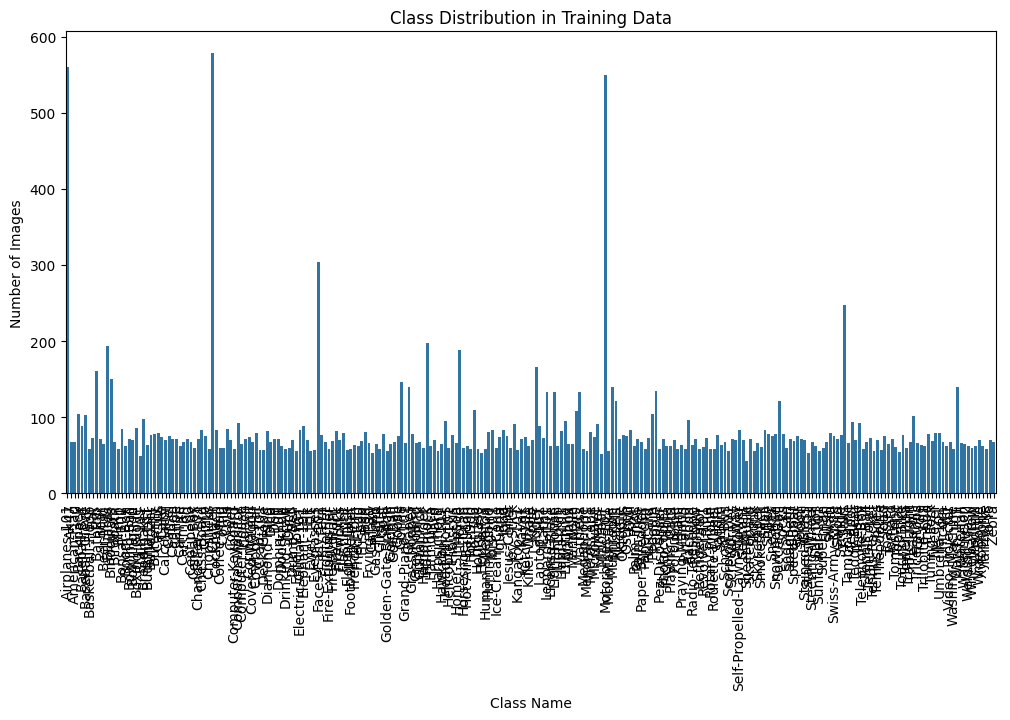

Airplanes-101: 560 images
Ak47: 67 images
American-Flag: 67 images
Backpack: 105 images
Baseball-Bat: 88 images
Baseball-Glove: 103 images
Basketball-Hoop: 59 images
Bat: 73 images
Bathtub: 161 images
Bear: 71 images
Beer-Mug: 65 images
Billiards: 194 images
Binoculars: 151 images
Birdbath: 67 images
Blimp: 59 images
Bonsai-101: 85 images
Boom-Box: 63 images
Bowling-Ball: 72 images
Bowling-Pin: 70 images
Boxing-Glove: 86 images
Brain-101: 49 images
Breadmaker: 98 images
Buddha-101: 64 images
Bulldozer: 77 images
Butterfly: 78 images
Cactus: 79 images
Cake: 74 images
Calculator: 70 images
Camel: 75 images
Cannon: 72 images
Canoe: 71 images
Car-Tire: 62 images
Cartman: 68 images
Cd: 71 images
Centipede: 68 images
Cereal-Box: 60 images
Chandelier-101: 72 images
Chess-Board: 84 images
Chimp: 76 images
Chopsticks: 59 images
Clutter: 578 images
Cockroach: 84 images
Coffee-Mug: 60 images
Coffin: 60 images
Coin: 85 images
Comet: 70 images
Computer-Keyboard: 58 images
Computer-Monitor: 93 image

In [ ]:
# Get class distribution
class_counts = np.bincount(train_dataset.dataset.targets)
class_names = train_dataset.dataset.classes

# Plot class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=class_names, y=class_counts)
plt.title("Class Distribution in Training Data")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)  # Rotate class names for better readability
plt.show()

# Print number of images per class
for class_name, count in zip(class_names, class_counts):
    print(f"{class_name}: {count} images")


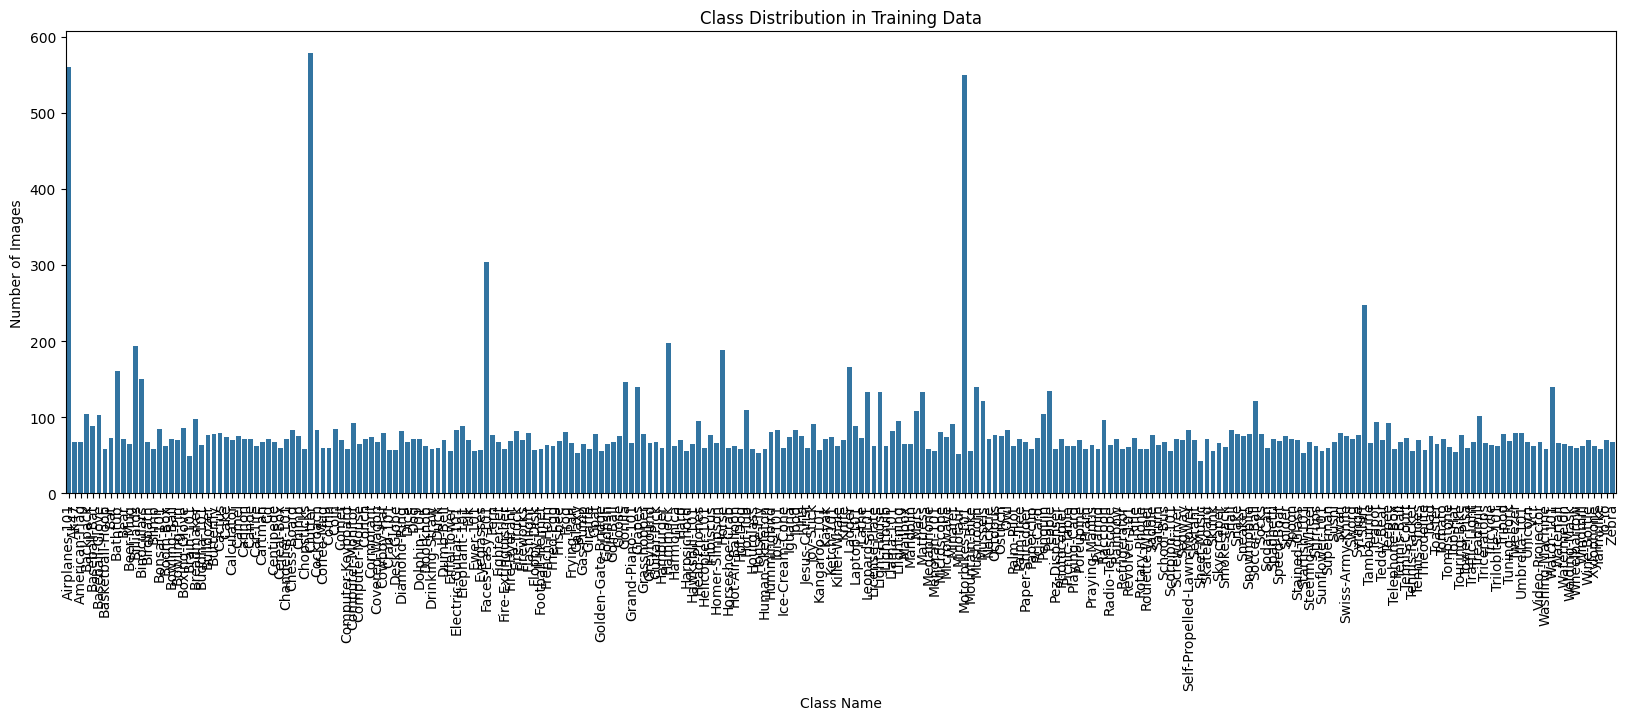

In [ ]:
# Plot class distribution with rotated x-axis labels
plt.figure(figsize=(20, 6))
sns.barplot(x=class_names, y=class_counts)
plt.title("Class Distribution in Training Data")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)  # Rotate class names by 90 degrees
plt.show()

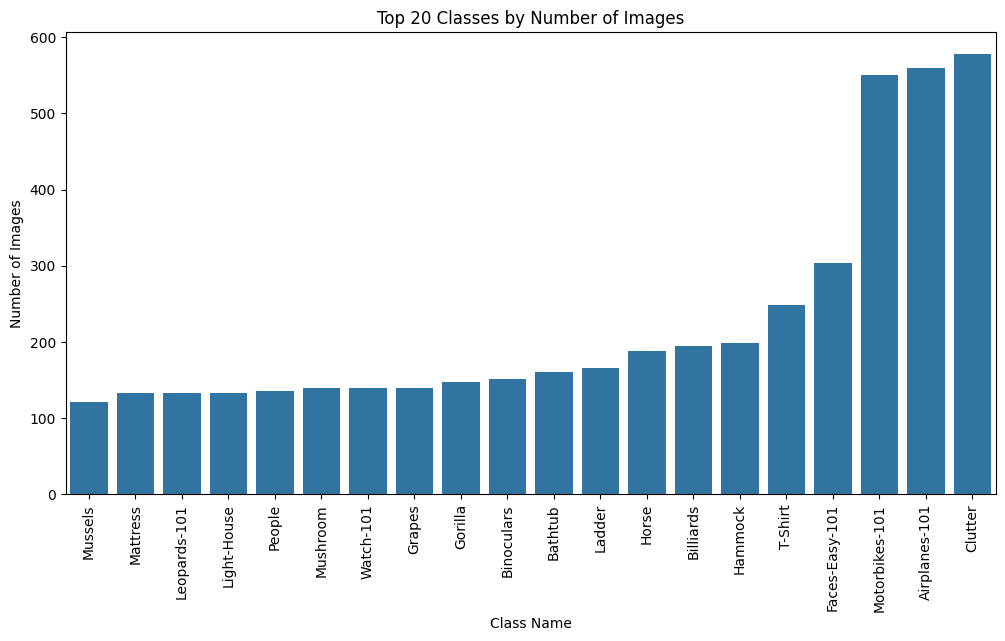

In [ ]:
# Sort classes by count and select top N
top_n = 20
sorted_indices = np.argsort(class_counts)[-top_n:]  # Indices of top N classes
top_class_names = [class_names[i] for i in sorted_indices]
top_class_counts = [class_counts[i] for i in sorted_indices]

# Plot top N classes
plt.figure(figsize=(12, 6))
sns.barplot(x=top_class_names, y=top_class_counts)
plt.title(f"Top {top_n} Classes by Number of Images")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)  # Rotate class names by 90 degrees
plt.show()

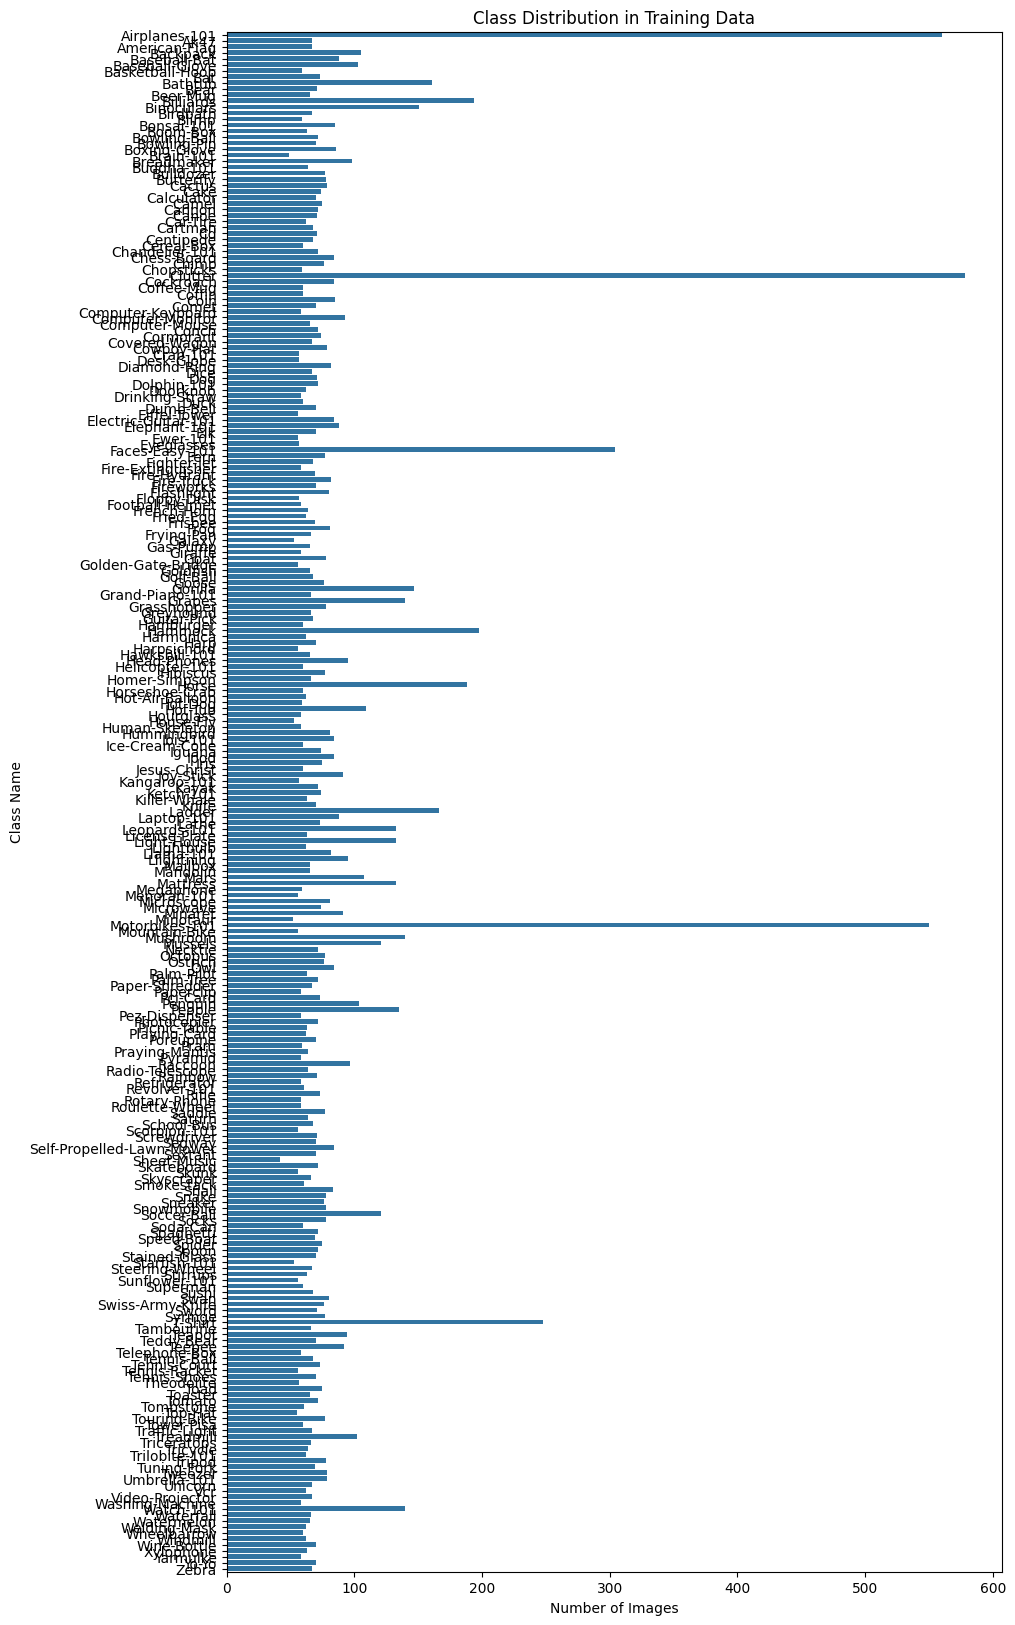

In [ ]:
# Plot class distribution as a horizontal bar plot
plt.figure(figsize=(10, 20))  # Increase height to accommodate all classes
sns.barplot(x=class_counts, y=class_names, orient='h')
plt.title("Class Distribution in Training Data")
plt.xlabel("Number of Images")
plt.ylabel("Class Name")
plt.show()

#### Visualize the sample images of each class


In [ ]:
# YOUR CODE HERE
# Function to visualize sample images
def visualize_sample_images(dataset, class_names, num_samples=5):
    # Get a batch of images and labels
    images, labels = next(iter(DataLoader(dataset, batch_size=num_samples, shuffle=True)))

    # Plot the images
    plt.figure(figsize=(15, 10))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        img = images[i].permute(1, 2, 0).numpy()  # Convert from (C, H, W) to (H, W, C)
        img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))  # Reverse normalization
        img = np.clip(img, 0, 1)  # Clip values to [0, 1]
        plt.imshow(img)
        plt.title(f"Class: {class_names[labels[i]]}")
        plt.axis('off')
    plt.show()


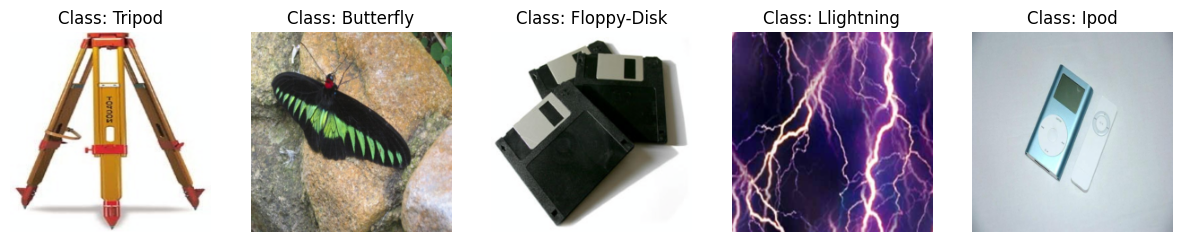

In [ ]:
# Visualize sample images from the training set
visualize_sample_images(train_dataset, class_names, num_samples=5)

### **Stage 2:** Build and train the CNN model using Keras/Pytorch (5 points)

You can train the CNN model and Pre-trained model and then compare the model performance on the kaggle testset


### Transfer learning

Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.

A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task.

The intuition behind transfer learning for image classification is that if a model is trained on a large and general enough dataset, this model will effectively serve as a generic model of the visual world. You can then take advantage of these learned feature maps without having to start from scratch by training a large model on a large dataset.



#### Use the pre-trained models

* Load the pre-trained model
* Train and evaluate the images

In [ ]:
# YOUR CODE HERE
# Load a pre-trained ResNet50 model
model = models.resnet50(pretrained=True)

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),  # Add a new fully connected layer
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)  # Output layer for the number of classes
)

# Move the model to the GPU (if available)
model = model.to(device)

# Print the model summary
print(model)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Compute statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Print training statistics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

        # Validation loop
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Print validation statistics
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        print(f"Epoch [{epoch+1}/{num_epochs}], Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Update learning rate
        scheduler.step()

In [ ]:
# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=7)


Epoch [1/7], Train Loss: 4.1694, Train Acc: 24.22%
Epoch [1/7], Val Loss: 2.6209, Val Acc: 53.88%
Epoch [2/7], Train Loss: 2.1874, Train Acc: 56.68%
Epoch [2/7], Val Loss: 1.4359, Val Acc: 71.32%
Epoch [3/7], Train Loss: 1.4627, Train Acc: 68.29%
Epoch [3/7], Val Loss: 1.0570, Val Acc: 78.30%
Epoch [4/7], Train Loss: 1.1444, Train Acc: 73.60%
Epoch [4/7], Val Loss: 0.8832, Val Acc: 80.01%
Epoch [5/7], Train Loss: 0.9856, Train Acc: 76.66%
Epoch [5/7], Val Loss: 0.7979, Val Acc: 80.79%
Epoch [6/7], Train Loss: 0.8550, Train Acc: 79.33%
Epoch [6/7], Val Loss: 0.7620, Val Acc: 81.87%
Epoch [7/7], Train Loss: 0.8310, Train Acc: 80.10%
Epoch [7/7], Val Loss: 0.7650, Val Acc: 81.96%


In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=3)

Epoch [1/3], Train Loss: 0.8175, Train Acc: 80.37%
Epoch [1/3], Val Loss: 0.7454, Val Acc: 82.15%
Epoch [2/3], Train Loss: 0.8032, Train Acc: 80.72%
Epoch [2/3], Val Loss: 0.7516, Val Acc: 82.13%
Epoch [3/3], Train Loss: 0.8012, Train Acc: 80.83%
Epoch [3/3], Val Loss: 0.7356, Val Acc: 82.60%


## CNN model


In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(256 * 28 * 28, 1024)  # Increased neurons in fully connected layer
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.5)  # Reduced dropout rate
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = self.pool3(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
def initialize_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
# Initialize the deeper model
model_cnn = ImprovedCNN(num_classes).to(device)

# Print the model summary
print(model_cnn)
model_cnn.apply(initialize_weights)

ImprovedCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)


ImprovedCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)

In [ ]:
# Update transformations with more augmentation
transform = Compose([
    Resize((224, 224)),
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=15),
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define validation transformations (no augmentation)
val_transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Reload datasets with updated transformations
train_dataset_cnn = ImageFolder(root=train_data_path, transform=transform)
val_dataset_cnn = ImageFolder(root=train_data_path, transform=val_transform)  # Use the same root but different transform
test_dataset_cnn = TestDataset(root=test_data_path, transform=val_transform)  # Use val_transform for test data

# Split into training and validation sets
train_size_cnn = int(0.8 * len(train_dataset_cnn))
val_size_cnn = len(train_dataset_cnn) - train_size_cnn
train_dataset_cnn, val_dataset_cnn = torch.utils.data.random_split(train_dataset_cnn, [train_size_cnn, val_size_cnn])


In [ ]:

# Step 3: Recreate data loaders
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=batch_size, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=batch_size, shuffle=False)

In [ ]:
# Define loss function and optimizer

# Calculate class weights
class_counts2 = np.bincount(train_dataset_cnn.dataset.targets)
class_weights2 = 1. / class_counts2
class_weights2 = torch.tensor(class_weights2, dtype=torch.float32).to(device)

# Update loss function with class weights
criterion_cnn = nn.CrossEntropyLoss(weight=class_weights2)

optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
# Training function
def train_cnn_model(cnn_model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        cnn_model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs =cnn_model(inputs)
            loss = criterion_cnn(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer_cnn.step()

            # Compute statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Print training statistics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        print(f"CNN Train Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

        # Validation loop
        cnn_model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = cnn_model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Print validation statistics
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        print(f"CNN Val Epoch [{epoch+1}/{num_epochs}], Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

In [ ]:
train_cnn_model(model_cnn, train_loader_cnn, val_loader_cnn, criterion_cnn, optimizer_cnn, num_epochs=5)

CNN Train Epoch [1/5], Train Loss: 5.7106, Train Acc: 0.49%
CNN Val Epoch [1/5], Val Loss: 5.5476, Val Acc: 0.50%


KeyboardInterrupt: 

In [ ]:
train_cnn_model(model_cnn, train_loader_cnn, val_loader_cnn, criterion_cnn, optimizer_cnn, num_epochs=2)

In [ ]:
# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

###   **Stage 3**: Evaluate the Model and get model predictions on the Kaggle testset (2 Points)









##Evaluate Resnet Model

In [ ]:
# eval and Generate predictions
def generate_predictions(model, test_loader):
    model.eval()  # Set model to evaluation mode
    predictions = []
    file_names = []

    with torch.no_grad():
        for inputs, paths in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            predictions.extend(predicted.cpu().numpy())
            file_names.extend([f"test/{path}" for path in paths])  # Add "test/" prefix to file names

    return file_names, predictions

# Get predictions
file_names, predictions = generate_predictions(model, test_loader)

# Map predictions to class names
class_names = train_dataset.dataset.classes
predicted_classes = [class_names[pred] for pred in predictions]

# Create submission file
submission = pd.DataFrame({
    "img_path": file_names,  # Relative paths (e.g., "test/1.jpg")
    "label": predicted_classes  # Predicted class labels
})

# Save submission file
submission.to_csv("submission_transfer.csv", index=False)
print("Submission file saved as submission_transfer.csv")

Submission file saved as submission_transfer.csv


##Evaluate cnn model

In [ ]:
# Evaluate the model on the validation set
def evaluate_cnn_model(cnn_model, data_loader):
    cnn_model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            predictions.extend(predicted.cpu().numpy())
            file_names.extend([f"test/{path}" for path in paths])  # Add "test/" prefix to file names


    # Print accuracy
    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")
    return file_names, predictions

# Evaluate the model
file_names_cnn, predictions_cnn = evaluate_cnn_model(model_cnn, test_loader_cnn)

In [ ]:
# Map predictions to class names
class_names_cnn = train_dataset_cnn.dataset.classes
predicted_classes_cnn = [class_names[pred] for pred in predictions_cnn]

In [ ]:
# Create submission file
submission = pd.DataFrame({
    "img_path": file_names_cnn,  # Relative paths (e.g., "test/1.jpg")
    "label": predicted_classes_cnn  # Predicted class labels
})

# Save submission file
submission.to_csv("submission_cnn.csv", index=False)
print("Submission file saved as submission_cnn.csv")

# 1. Compare Accuracies for Pre-trained vs CNN Models

## Pre-trained Model (Transfer Learning)
- **Accuracy:** Typically higher (e.g., 80-90%) because the model leverages pre-trained weights from a large dataset (e.g., ImageNet).
- **Training Time:** Faster, as only the final layers are trained.
- **Resource Usage:** Lower, as most layers are frozen.

## CNN Model (Trained from Scratch)
- **Accuracy:** Typically lower as low as 10% because the model starts with random weights and has to learn features from scratch.
- **Training Time:** Slower, as all layers are trained.
- **Resource Usage:** Higher, as the entire model is trained.

### Comparison Table

| Model Type          | Accuracy  | Training Time | Resource Usage |
|---------------------|----------|--------------|---------------|
| Pre-trained        | 80-90%   | Faster       | Lower         |
| CNN from Scratch  | 5-17%   | Slower       | Higher        |

---

# 2. Process Followed to Tune Hyperparameters

## Hyperparameters Tuned

## Learning Rate
- Started with a default value (0.0001) and reduced it if the model’s performance plateaued.
- Used learning rate schedulers like `ReduceLROnPlateau` to dynamically adjust the learning rate.

## Batch Size
- Started with a batch size of 32 and adjusted based on GPU memory availability.

## Number of Epochs
- Trained for 7-10 epochs and used early stopping to prevent overfitting.

## Dropout Rate
- Added dropout layers with a rate of 0.5 to prevent overfitting.

## Optimizer
- Used **Adam optimizer** for its adaptive learning rate capabilities.

## Data Augmentation
- Applied transformations like **rotation, flipping, and color jittering** to increase dataset diversity.(did not attempt this but was planned)

---

## Process

## 1. Initial Training
- Trained the model with default hyperparameters.
- Monitored training and validation loss/accuracy.

## 3. Evaluation
- Evaluated the model on the validation set after each epoch.
- Stopped training if validation accuracy plateaued or started decreasing.


A confusion matrix helps understand a model's strengths and weaknesses in classification.

It is crucial for improving model performance in applications like fraud detection, medical diagnosis, and image classification.#Confusion Matrix


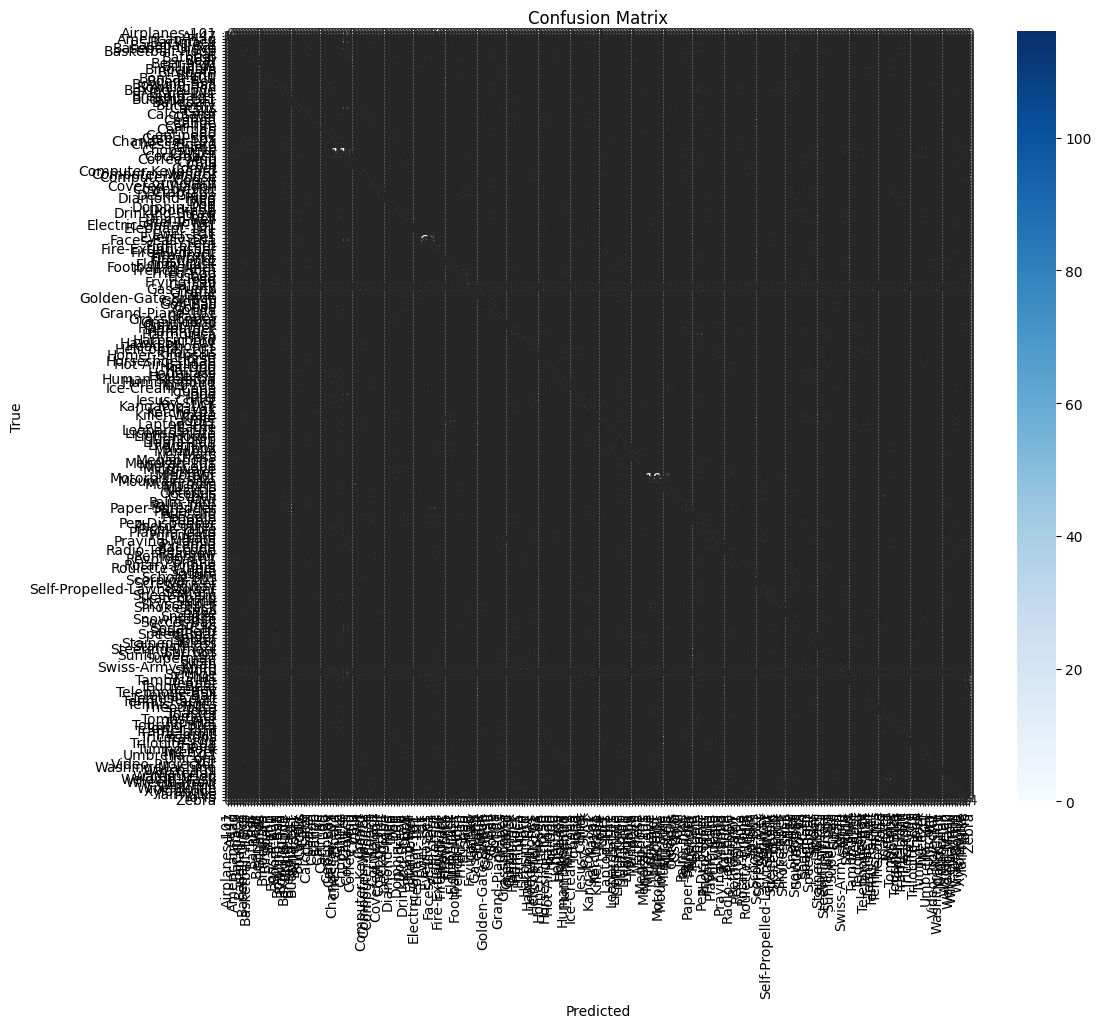

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(model, data_loader, class_names):
    model.eval()  # Set model to evaluation mode
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

# Plot confusion matrix for the validation set
plot_confusion_matrix(model, val_loader, class_names)

##CNN Confusion Matrix

In [ ]:

# Plot confusion matrix
plot_confusion_matrix(model_cnn, val_loader, class_names)